# `Taller 2` — Limpieza y tratamiento de datos

## Materia:

- Métodos Estadísticos para Analisis de Datos

## Docente

- **Nombre**: Julian Hoyos

## Estudiantes

- Jose David Losada Legarda 76261004
- Yaneth Viviana Pechene Cuchumbe 76261010
- Darlyn Kamila Mamian Uni 76261009

### Objetivo

Aplicar el flujo completo de limpieza sobre un dataset real con múltiples problemas de calidad. La sesión trabaja exploración, nulos, tipos incorrectos, valores especiales, errores de codificación, categorías inválidas, outliers físicamente imposibles y duplicados.

| Columna                    | Tipo esperado      | Descripción                         |
| -------------------------- | ------------------ | ----------------------------------- |
| Edad                       | numérico           | Edad del trabajador en años         |
| Tipo de trabajador         | categórico         | Sector o tipo de empleo             |
| Nivel Educativo            | categórico         | Máximo nivel de educación alcanzado |
| Salario por hora           | numérico           | Salario por hora en pesos           |
| Estado civil               | categórico         | Estado civil del trabajador         |
| Sexo                       | categórico         | Sexo del trabajador                 |
| Personas a cargo           | numérico           | Número de personas a cargo          |
| Semanas trabajadas por año | numérico           | Semanas trabajadas en el último año |
| **Buen Desempeño**         | categórico binaria | **Variable objetivo**, Si o No      |


### Carga del dataset

Se carga desde el CSV ubicado en `data/raw/`. La columna `Buen\nDesempeño` viene con un salto de línea en el nombre, lo cual rompe filtros y consultas posteriores. Se renombra de inmediato.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

df = pd.read_csv("../data/raw/datos_taller.csv")
df = df.rename(columns={"Buen\nDesempeño": "Buen Desempeño"})

print(f"Dimensiones: {df.shape}")
df.head()


Dimensiones: (20000, 10)


,Unnamed: 0,Edad,Tipo de trabajador,Nivel Educativo,Salario por hora,Estado civil,Sexo,Personas a cargo,Semanas trabajadas por año,Buen Desempeño
0,NaN,69,Privado,9 grado,678,Divorciado,Femenino,2,52,No
1,NaN,36,Independiente,Universitario sin graduar,1818,Soltero,Masculino,1,52,Si
2,NaN,18,Privado,Universitario,6137,Soltero,Femenino,2,45,Si
3,NaN,29,Desconocido,10 grado,5208,Soltero,Femenino,1,42,No
4,NaN,47,Desconocido,Niño,9863,Soltero,Masculino,0,26,No


### Exploración inicial

Antes de cualquier transformación se obtiene una vista panorámica del dataset. Interesa identificar tipos asignados por pandas, presencia de nulos y comportamiento general de las variables.


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  0 non-null      float64
 1   Edad                        20000 non-null  str    
 2   Tipo de trabajador          20000 non-null  str    
 3   Nivel Educativo             20000 non-null  str    
 4   Salario por hora            20000 non-null  str    
 5   Estado civil                19999 non-null  str    
 6   Sexo                        20000 non-null  str    
 7   Personas a cargo            20000 non-null  int64  
 8   Semanas trabajadas por año  20000 non-null  int64  
 9   Buen Desempeño              20000 non-null  str    
dtypes: float64(1), int64(2), str(7)
memory usage: 1.5 MB


In [3]:
df.describe(include="all")


,Unnamed: 0,Edad,Tipo de trabajador,Nivel Educativo,Salario por hora,Estado civil,Sexo,Personas a cargo,Semanas trabajadas por año,Buen Desempeño
count,0.0,20000,20000,20000,20000,19999,20000,20000.000000,20000.000000,20000
unique,NaN,55,10,18,8533,10,4,NaN,NaN,2
top,NaN,64,Desconocido,Bachiller,500,Soltero,Femenino,NaN,NaN,No
freq,NaN,405,10076,4930,69,8647,10506,NaN,NaN,10032
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.941700,38.163550,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.360631,13.078026,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,12.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,26.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,42.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,52.000000,NaN


Tres observaciones inmediatas saltan del `info()`.

`Unnamed: 0` tiene 0 valores no nulos, es decir, está completamente vacía y debe eliminarse.

`Edad` y `Salario por hora` aparecen como tipo `object` (texto) cuando deberían ser numéricas. Esto suele indicar que contienen valores no numéricos mezclados con los números.

`Estado civil` reporta 1 valor faltante.


### Nulos y duplicados

Chequeo formal de la calidad básica del dataset.


In [4]:
print("Nulos por columna:")
print(df.isnull().sum())

print(f"\nFilas duplicadas: {df.duplicated().sum()}")


Nulos por columna:
Unnamed: 0                    20000
Edad                              0
Tipo de trabajador                0
Nivel Educativo                   0
Salario por hora                  0
Estado civil                      1
Sexo                              0
Personas a cargo                  0
Semanas trabajadas por año        0
Buen Desempeño                    0
dtype: int64

Filas duplicadas: 2


El dataset trae 1 nulo en `Estado civil` y 2 filas completamente duplicadas. Los duplicados no aparecían en el análisis del notebook original, conviene eliminarlos al inicio para que no inflen artificialmente las distribuciones.


### Distribución del target

El target es `Buen Desempeño`, una variable binaria con valores `Si` y `No`. Antes de pasar a los predictores, conviene confirmar que las clases estén razonablemente balanceadas. Un desbalance fuerte cambia las métricas de evaluación y puede requerir técnicas como sobremuestreo.


Distribución de Buen Desempeño:
  No     10032 (50.2%)
  Si      9968 (49.8%)


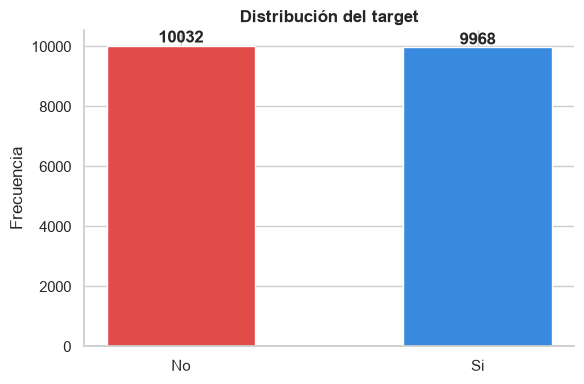

In [5]:
conteo_target = df["Buen Desempeño"].value_counts()
pct_target = df["Buen Desempeño"].value_counts(normalize=True).round(3) * 100

print("Distribución de Buen Desempeño:")
for clase in conteo_target.index:
    print(f"  {clase:<5} {conteo_target[clase]:>6} ({pct_target[clase]:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(conteo_target.index, conteo_target.values, color=["#E24B4A", "#378ADD"], width=0.5)
for i, (clase, val) in enumerate(conteo_target.items()):
    ax.text(i, val + 100, str(val), ha="center", fontweight="bold")
ax.set_title("Distribución del target", fontweight="bold")
ax.set_ylabel("Frecuencia")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


El target está prácticamente balanceado, 50.2% No y 49.8% Si. No habrá problemas de clases minoritarias, las métricas estándar como accuracy y F1 funcionarán bien.


### Exploración gráfica de variables categóricas

Se grafican las frecuencias para detectar a simple vista categorías inválidas o sospechosamente pequeñas.


Resumen de variables categóricas:
Variable                        Categorías únicas    NAs
----------------------------------------------------------
Tipo de trabajador                             10      0
Nivel Educativo                                18      0
Estado civil                                   10      1
Sexo                                            4      0
Buen Desempeño                                  2      0


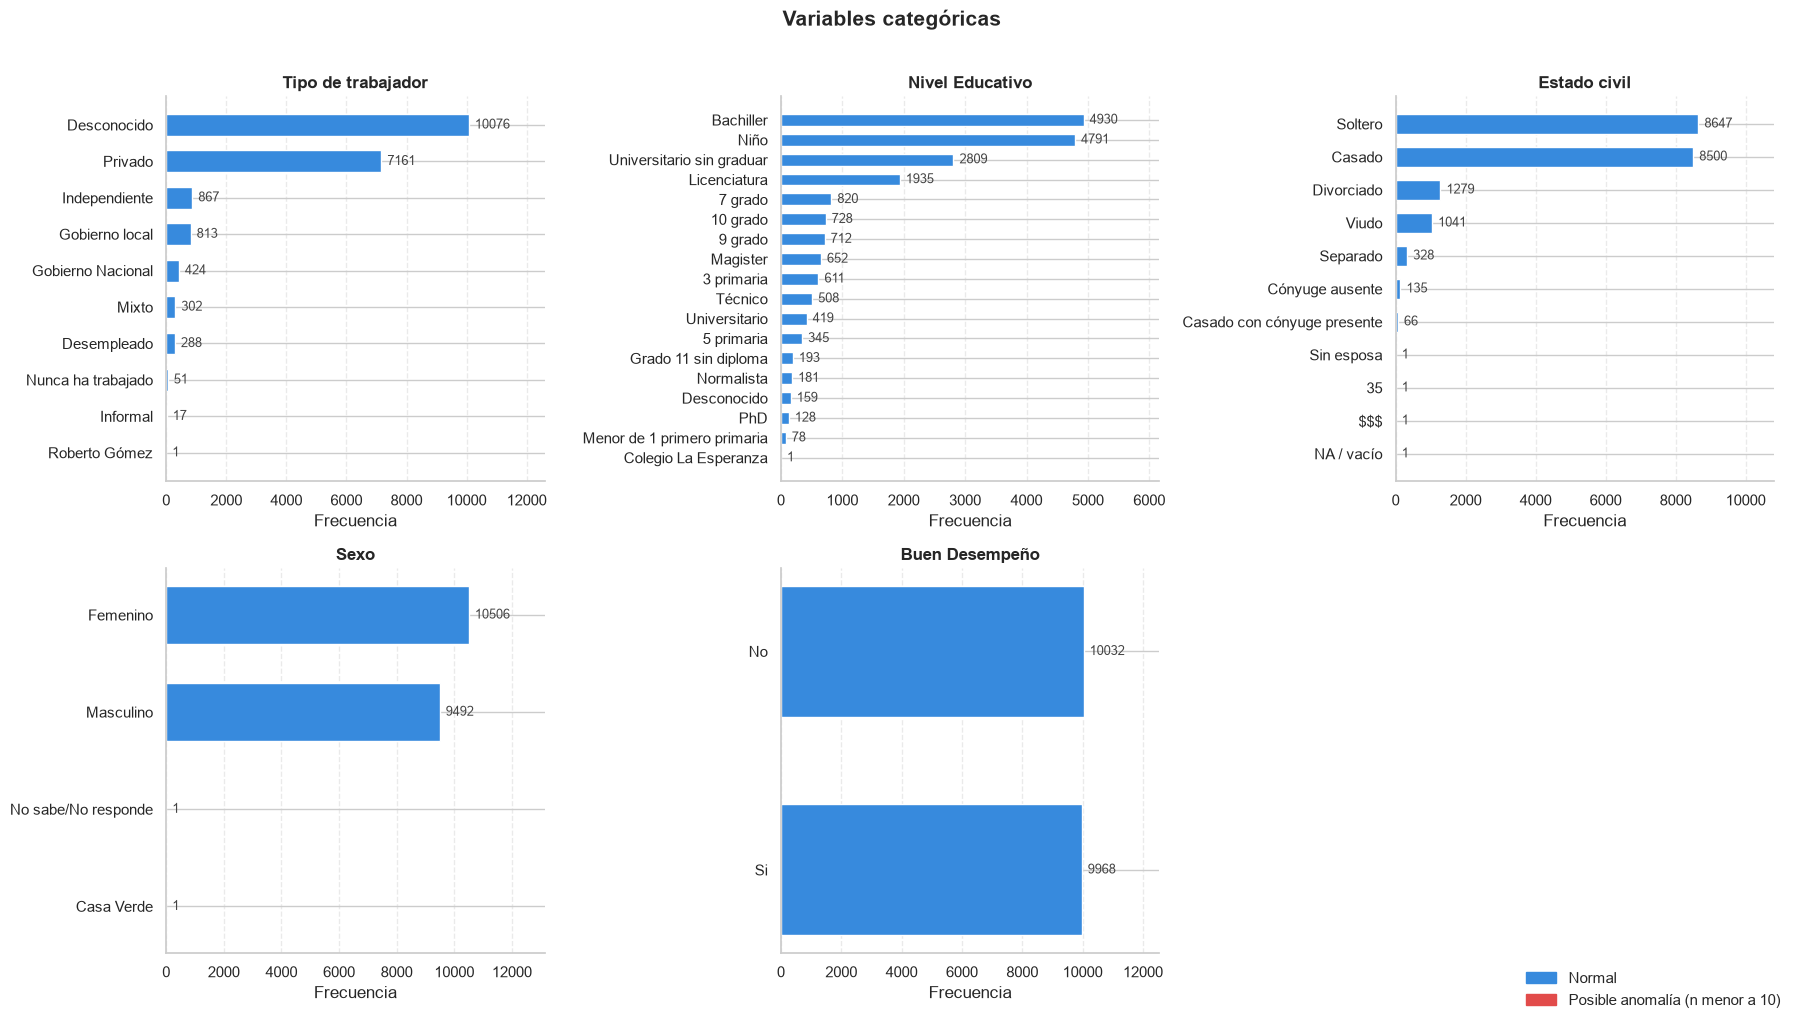

In [6]:
cat_vars = ["Tipo de trabajador", "Nivel Educativo", "Estado civil", "Sexo", "Buen Desempeño"]

print("Resumen de variables categóricas:")
print(f"{'Variable':<30} {'Categorías únicas':>18} {'NAs':>6}")
print("-" * 58)
for v in cat_vars:
    print(f"{v:<30} {df[v].nunique():>18} {df[v].isna().sum():>6}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    ax = axes[i]
    conteo = df[var].fillna("NA / vacío").value_counts().sort_values()
    colores = [
        "#E24B4A" if (v == "NA / vacío" or conteo[v] < 10) else "#378ADD" for v in conteo.index
    ]

    bars = ax.barh(conteo.index.astype(str), conteo.values, color=colores, height=0.6)
    for bar, val in zip(bars, conteo.values):
        ax.text(
            bar.get_width() + conteo.max() * 0.02,
            bar.get_y() + bar.get_height() / 2,
            str(val),
            va="center",
            ha="left",
            fontsize=9,
            color="#444",
        )

    ax.set_title(var, fontsize=12, fontweight="bold")
    ax.set_xlabel("Frecuencia")
    ax.set_xlim(0, conteo.max() * 1.25)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

axes[-1].set_visible(False)

parche_normal = mpatches.Patch(color="#378ADD", label="Normal")
parche_anomalia = mpatches.Patch(color="#E24B4A", label="Posible anomalía (n menor a 10)")
fig.legend(handles=[parche_normal, parche_anomalia], loc="lower right", fontsize=11, frameon=False)
fig.suptitle("Variables categóricas", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


Los gráficos confirman que hay varios valores con frecuencia 1 marcados en rojo. Esos son candidatos a errores de codificación, se inspeccionan en detalle en el siguiente bloque.


### Identificación de valores inválidos por columna

Se revisa el `value_counts` de cada categórica para detectar valores que no corresponden a categorías reales.


In [7]:
for col in ["Tipo de trabajador", "Nivel Educativo", "Estado civil", "Sexo"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))



--- Tipo de trabajador ---
Tipo de trabajador
Desconocido           10076
Privado                7161
Independiente           867
Gobierno local          813
Gobierno Nacional       424
Mixto                   302
Desempleado             288
Nunca ha trabajado       51
Informal                 17
Roberto Gómez             1
Name: count, dtype: int64

--- Nivel Educativo ---
Nivel Educativo
Bachiller                      4930
Niño                           4791
Universitario sin graduar      2809
Licenciatura                   1935
7 grado                         820
10 grado                        728
9 grado                         712
Magister                        652
3 primaria                      611
Técnico                         508
Universitario                   419
5 primaria                      345
Grado 11 sin diploma            193
Normalista                      181
Desconocido                     159
PhD                             128
Menor de 1 primero primaria   

Los valores inválidos encontrados son los siguientes.

`Sexo`. Los valores `Casa Verde` y `No sabe/No responde` no son categorías válidas.

`Estado civil`. Los valores `$$$`, `35` (entero, no string) y `Sin esposa` son errores de codificación.

`Tipo de trabajador`. El valor `Roberto Gómez` es un nombre propio en un campo categórico.

`Nivel Educativo`. El valor `Colegio La Esperanza` es una institución, no un nivel educativo.

Además aparecen dos casos masivos que merecen un análisis más profundo, `Desconocido` en Tipo de trabajador (50% del dataset) y `Niño` en Nivel Educativo (24% del dataset).


### Investigación del valor `Niño` en Nivel Educativo

`Niño` aparece en 4791 registros. Si fuera literal, significaría que el 24% del dataset son menores con salario y semanas trabajadas, lo cual no tiene sentido. Se verifica cruzando con la edad.


In [8]:
ninos = df[df["Nivel Educativo"] == "Niño"].copy()
ninos["Edad_num"] = pd.to_numeric(ninos["Edad"], errors="coerce")

print(f"Total registros con 'Niño': {len(ninos)}")
print(f"\nEstadísticas de edad de los 'Niño':")
print(ninos["Edad_num"].describe().round(1))

salario_num = pd.to_numeric(ninos["Salario por hora"], errors="coerce")
print(f"\nDe los 'Niño', cuántos tienen salario mayor a 0: {(salario_num > 0).sum()}")


Total registros con 'Niño': 4791

Estadísticas de edad de los 'Niño':
count    4791.0
mean       43.9
std        15.1
min       -10.0
25%        31.0
50%        44.0
75%        57.0
max        70.0
Name: Edad_num, dtype: float64

De los 'Niño', cuántos tienen salario mayor a 0: 4789


Los `Niño` tienen edad mediana de 44 años y un rango de 18 a 70. Además, 4789 de 4791 tienen salario positivo. Queda claro que `Niño` es un error de codificación, no un valor literal. Probablemente representa personas sin estudios formales registrados. Para esta sesión se reasigna a `Desconocido`, categoría que ya existe en la columna para casos no clasificados.


### Valores no numéricos en `Edad` y `Salario por hora`

Las columnas figuran como `object`. Se identifican los valores específicos que impiden la conversión.


In [9]:
edad_no_num = df["Edad"][pd.to_numeric(df["Edad"], errors="coerce").isna()]
sal_no_num = df["Salario por hora"][pd.to_numeric(df["Salario por hora"], errors="coerce").isna()]

print(f"Edad, valores no numéricos: {edad_no_num.value_counts().to_dict()}")
print(f"Salario, valores no numéricos: {sal_no_num.value_counts().to_dict()}")


Edad, valores no numéricos: {'Maduro': 1}
Salario, valores no numéricos: {'Muy poco': 1}


`Edad` contiene `Maduro` y `Salario por hora` contiene `Muy poco`. Ambos son descripciones cualitativas en campos numéricos. Se convertirán a NaN durante el cast y luego se imputarán con la mediana.


### Valores físicamente imposibles

Independiente de los outliers estadísticos, conviene chequear valores que no pueden existir en la realidad. Una edad o un salario negativos son siempre errores.


In [10]:
edad_num = pd.to_numeric(df["Edad"], errors="coerce")
sal_num = pd.to_numeric(df["Salario por hora"], errors="coerce")

print(f"Edades negativas: {(edad_num < 0).sum()} → {edad_num[edad_num < 0].tolist()}")
print(f"Salarios negativos: {(sal_num < 0).sum()} → {sal_num[sal_num < 0].tolist()}")


Edades negativas: 1 → [-10.0]
Salarios negativos: 1 → [-7600.0]


Hay 1 edad negativa (`-10`) y 1 salario negativo (`-7600`). Se reemplazan por la mediana de cada variable calculada sobre los valores válidos.


### Boxplots de numéricas para outliers estadísticos


Resumen IQR de variables numéricas:
Variable                             Q1       Q3      IQR   Lim. inf   Lim. sup   Outliers
------------------------------------------------------------------------------------
Edad                               31.0     57.0     26.0       -8.0       96.0          1
Salario por hora                 2127.5   7384.0   5256.5    -5757.2    15268.8          2
Personas a cargo                    0.0      4.0      4.0       -6.0       10.0          0
Semanas trabajadas por año         26.0     52.0     26.0      -13.0       91.0          0


/var/folders/8q/0h00n1_j1tg40d1vdfzf0db40000gn/T/ipykernel_8238/3868983101.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(
/var/folders/8q/0h00n1_j1tg40d1vdfzf0db40000gn/T/ipykernel_8238/3868983101.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(
/var/folders/8q/0h00n1_j1tg40d1vdfzf0db40000gn/T/ipykernel_8238/3868983101.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(
/var/folders/8q/0h00n1_j1tg40d1vdfzf0db40000gn/T/ipykernel_8238/3868983101.py:23: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizonta

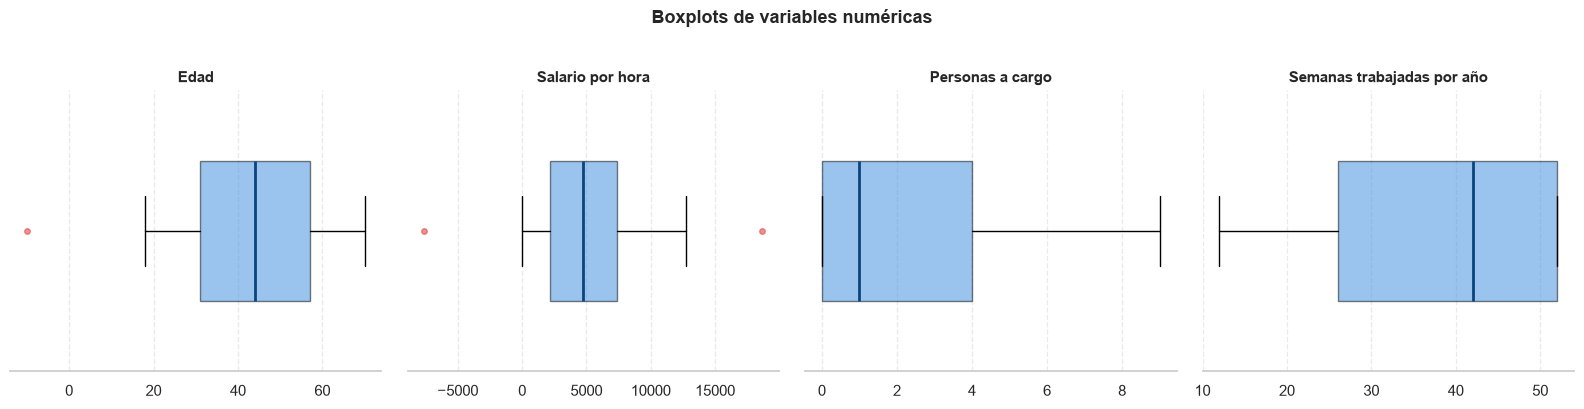

In [11]:
df_num = df.copy()
df_num["Edad"] = pd.to_numeric(df_num["Edad"], errors="coerce")
df_num["Salario por hora"] = pd.to_numeric(df_num["Salario por hora"], errors="coerce")

num_vars = ["Edad", "Salario por hora", "Personas a cargo", "Semanas trabajadas por año"]

print("Resumen IQR de variables numéricas:")
print(
    f"{'Variable':<30} {'Q1':>8} {'Q3':>8} {'IQR':>8} {'Lim. inf':>10} {'Lim. sup':>10} {'Outliers':>10}"
)
print("-" * 84)
for var in num_vars:
    col = df_num[var].dropna()
    q1, q3 = col.quantile([0.25, 0.75])
    iqr = q3 - q1
    li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((col < li) | (col > ls)).sum()
    print(f"{var:<30} {q1:>8.1f} {q3:>8.1f} {iqr:>8.1f} {li:>10.1f} {ls:>10.1f} {n_out:>10}")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, var in enumerate(num_vars):
    ax = axes[i]
    bp = ax.boxplot(
        df_num[var].dropna(),
        vert=False,
        patch_artist=True,
        widths=0.5,
        flierprops=dict(
            marker="o",
            markerfacecolor="#E24B4A",
            markeredgecolor="#E24B4A",
            markersize=4,
            alpha=0.6,
        ),
    )
    bp["boxes"][0].set_facecolor("#378ADD")
    bp["boxes"][0].set_alpha(0.5)
    bp["medians"][0].set_color("#0C447C")
    bp["medians"][0].set_linewidth(2)
    ax.set_title(var, fontsize=11, fontweight="bold")
    ax.set_yticks([])
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

fig.suptitle("Boxplots de variables numéricas", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


Los outliers estadísticos de `Salario por hora` corresponden a salarios reales en la cola alta de la distribución, no a errores. Por tratarse de datos socioeconómicos, se conservan. `Edad`, `Personas a cargo` y `Semanas trabajadas por año` no presentan outliers preocupantes según IQR.


### Decisiones de limpieza

A continuación se resumen las decisiones con su justificación.

**Eliminar `Unnamed: 0`.** Columna completamente vacía, sin información.

**Eliminar duplicados.** Hay 2 filas exactamente iguales. Inflan artificialmente las distribuciones.

**Convertir `Edad` y `Salario por hora` a numérico.** Los valores no numéricos `Maduro` y `Muy poco` quedan como NaN y se imputan con la mediana.

**Reemplazar valores negativos por la mediana.** Edad de `-10` y salario de `-7600` son físicamente imposibles.

**Imputar el nulo de `Estado civil`.** Es un solo registro, se imputa con la moda.

**Reemplazar valores inválidos de categóricas y luego imputar con moda.** Aplica a `Casa Verde` y `No sabe/No responde` en Sexo, a `$$$`, `35` (entero) y `Sin esposa` en Estado civil, a `Roberto Gómez` en Tipo de trabajador y a `Colegio La Esperanza` en Nivel Educativo.

**Reasignar `Niño` a `Desconocido` en Nivel Educativo.** 4791 personas con edades adultas y salario no pueden ser niños, es un error de codificación.

**Unificar categorías de casados.** `Casado`, `Casado con cónyuge presente` y `Cónyuge ausente` se agrupan en `Casado`. Las dos últimas son apenas 201 registros.

**Conservar `Desconocido` en Tipo de trabajador.** Aunque representa el 50% del dataset, eliminarlo destruiría la mitad de las observaciones. Se mantiene como categoría explícita para que el modelo pueda aprender de ese grupo.

**Conservar outliers estadísticos de salario.** Son datos reales en la cola alta de la distribución, no errores.


### Aplicación de la limpieza


In [12]:
df = df.drop(columns=["Unnamed: 0"])
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape tras eliminar duplicados: {df.shape}")


Shape tras eliminar duplicados: (19998, 9)


In [13]:
df["Edad"] = pd.to_numeric(df["Edad"], errors="coerce")
df["Salario por hora"] = pd.to_numeric(df["Salario por hora"], errors="coerce")

df.loc[df["Edad"] < 0, "Edad"] = np.nan
df.loc[df["Salario por hora"] < 0, "Salario por hora"] = np.nan

df["Edad"] = df["Edad"].fillna(df["Edad"].median())
df["Salario por hora"] = df["Salario por hora"].fillna(df["Salario por hora"].median())

print("Edad y Salario tras conversión e imputación:")
print(df[["Edad", "Salario por hora"]].describe().round(1))


Edad y Salario tras conversión e imputación:
          Edad  Salario por hora
count  19998.0           19998.0
mean      43.8            4807.3
std       15.2            2940.5
min       18.0               0.0
25%       31.0            2128.2
50%       44.0            4718.5
75%       57.0            7384.0
max       70.0           18654.0


In [14]:
df["Sexo"] = df["Sexo"].replace(["Casa Verde", "No sabe/No responde"], pd.NA)
df["Sexo"] = df["Sexo"].fillna(df["Sexo"].mode()[0])

df["Estado civil"] = df["Estado civil"].replace([35, "$$$", "Sin esposa"], pd.NA)
df["Estado civil"] = df["Estado civil"].replace(
    {"Casado con cónyuge presente": "Casado", "Cónyuge ausente": "Casado"}
)
df["Estado civil"] = df["Estado civil"].fillna(df["Estado civil"].mode()[0])

df["Tipo de trabajador"] = df["Tipo de trabajador"].replace("Roberto Gómez", pd.NA)
df["Tipo de trabajador"] = df["Tipo de trabajador"].fillna(df["Tipo de trabajador"].mode()[0])

df["Nivel Educativo"] = df["Nivel Educativo"].replace("Colegio La Esperanza", pd.NA)
df["Nivel Educativo"] = df["Nivel Educativo"].replace("Niño", "Desconocido")
df["Nivel Educativo"] = df["Nivel Educativo"].fillna(df["Nivel Educativo"].mode()[0])

print("Limpieza aplicada")


Limpieza aplicada


### Revisión final

Se valida que el dataset quedó sin nulos, sin duplicados, con los tipos correctos y sin los valores inválidos detectados.


In [15]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Edad                        19998 non-null  float64
 1   Tipo de trabajador          19998 non-null  str    
 2   Nivel Educativo             19998 non-null  str    
 3   Salario por hora            19998 non-null  float64
 4   Estado civil                19998 non-null  str    
 5   Sexo                        19998 non-null  str    
 6   Personas a cargo            19998 non-null  int64  
 7   Semanas trabajadas por año  19998 non-null  int64  
 8   Buen Desempeño              19998 non-null  str    
dtypes: float64(2), int64(2), str(5)
memory usage: 1.4 MB


In [16]:
print("Nulos restantes:")
print(df.isnull().sum())
print(f"\nDuplicados restantes: {df.duplicated().sum()}")


Nulos restantes:
Edad                          0
Tipo de trabajador            0
Nivel Educativo               0
Salario por hora              0
Estado civil                  0
Sexo                          0
Personas a cargo              0
Semanas trabajadas por año    0
Buen Desempeño                0
dtype: int64

Duplicados restantes: 0


In [17]:
print("Categorías finales por variable:\n")
for col in ["Tipo de trabajador", "Nivel Educativo", "Estado civil", "Sexo"]:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()


Categorías finales por variable:

--- Tipo de trabajador ---
Tipo de trabajador
Desconocido           10075
Privado                7161
Independiente           867
Gobierno local          813
Gobierno Nacional       424
Mixto                   302
Desempleado             288
Nunca ha trabajado       51
Informal                 17
Name: count, dtype: int64

--- Nivel Educativo ---
Nivel Educativo
Desconocido                    4949
Bachiller                      4930
Universitario sin graduar      2809
Licenciatura                   1935
7 grado                         820
10 grado                        728
9 grado                         712
Magister                        652
3 primaria                      611
Técnico                         508
Universitario                   419
5 primaria                      345
Grado 11 sin diploma            193
Normalista                      181
PhD                             128
Menor de 1 primero primaria      78
Name: count, dtype: int64

### Análisis de correlación entre variables

Como en Titanic y Diabetes, conviene verificar si hay variables fuertemente correlacionadas o derivadas que estén aportando información redundante. Este dataset tiene dos tipos de variables, así que se aplican dos métricas distintas.

Para variables numéricas se usa la correlación de Pearson, que va de `-1` a `1`.

Para variables categóricas se usa Cramér's V, basada en chi-cuadrado, que va de `0` (sin asociación) a `1` (dependencia perfecta).


#### Correlación entre variables numéricas


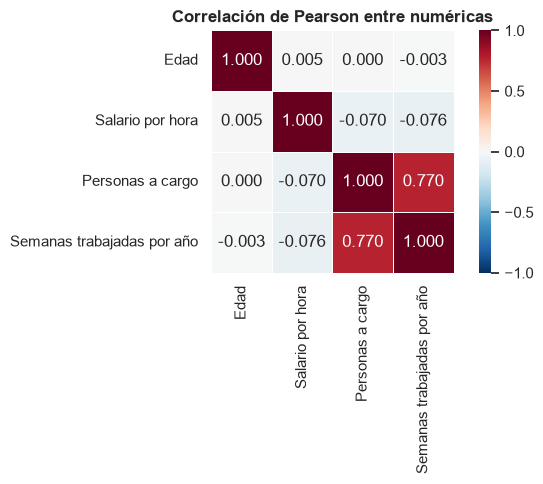

                             Edad  Salario por hora  Personas a cargo  \
Edad                        1.000             0.005              0.00   
Salario por hora            0.005             1.000             -0.07   
Personas a cargo            0.000            -0.070              1.00   
Semanas trabajadas por año -0.003            -0.076              0.77   

                            Semanas trabajadas por año  
Edad                                            -0.003  
Salario por hora                                -0.076  
Personas a cargo                                 0.770  
Semanas trabajadas por año                       1.000  


In [ ]:
num_vars = ["Edad", "Salario por hora", "Personas a cargo", "Semanas trabajadas por año"]

corr_num = df[num_vars].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_num,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlación de Pearson entre numéricas", fontweight="bold")
plt.tight_layout()
plt.show()

print(corr_num.round(3))


Salta a la vista una correlación de `0.770` entre `Personas a cargo` y `Semanas trabajadas por año`. Es un valor alto que merece investigación, ya que sugiere que las dos variables podrían estar midiendo lo mismo o estar derivadas una de otra.

El resto de pares numéricos muestra correlaciones prácticamente nulas, lo cual es esperable, no hay redundancia entre `Edad`, `Salario` y las demás.


#### Investigación de `Personas a cargo` vs `Semanas trabajadas`

Para entender la correlación, se cruzan las dos variables. Si la relación fuera lineal y limpia, el groupby mostraría un patrón claro.


In [ ]:
cruce = (
    df.groupby("Personas a cargo")["Semanas trabajadas por año"]
    .agg(["count", "mean", "min", "max"])
    .round(2)
)
print(cruce)


                  count   mean  min  max
Personas a cargo                        
0                  9684  25.26   12   35
1                  2313  50.03   40   52
2                   987  49.81   40   52
3                  1348  50.21   40   52
4                  1441  50.44   40   52
5                   618  50.36   40   52
6                  3603  50.53   40   52
7                     2  49.00   46   52
8                     1  52.00   52   52
9                     1  33.00   33   33


El resultado revela una regla artificial dentro del dataset.

Cuando `Personas a cargo = 0`, las semanas trabajadas siempre están entre `12` y `35`, con media de `25`.

Cuando `Personas a cargo >= 1`, las semanas trabajadas saltan a un rango entre `40` y `52`, con media cercana a `50`.

Esa separación tan limpia no es natural en datos reales, indica que las dos variables fueron generadas siguiendo una regla, probablemente `Personas a cargo` se asigna en base a si la persona trabaja muchas o pocas semanas, o viceversa. En cualquier caso, no son independientes. tocaria consultar con quien haya construido el dataset.


#### Asociación entre variables categóricas (Cramér's V)


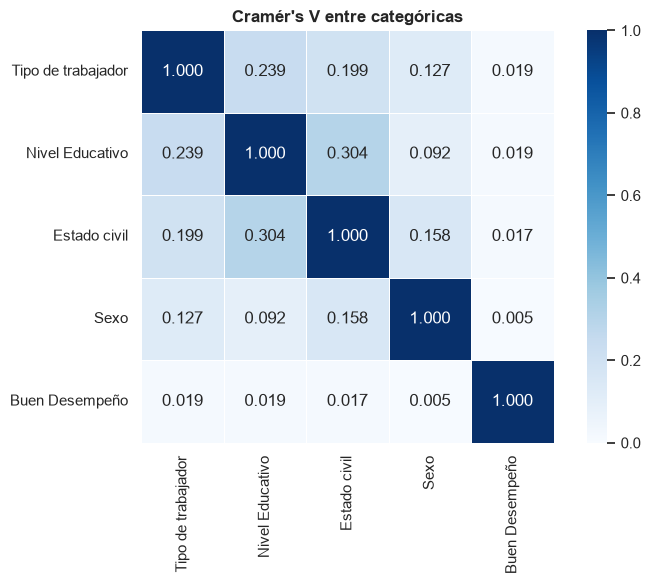

                    Tipo de trabajador  Nivel Educativo  Estado civil   Sexo  \
Tipo de trabajador               1.000            0.239         0.199  0.127   
Nivel Educativo                  0.239            1.000         0.304  0.092   
Estado civil                     0.199            0.304         1.000  0.158   
Sexo                             0.127            0.092         0.158  1.000   
Buen Desempeño                   0.019            0.019         0.017  0.005   

                    Buen Desempeño  
Tipo de trabajador           0.019  
Nivel Educativo              0.019  
Estado civil                 0.017  
Sexo                         0.005  
Buen Desempeño               1.000  


In [ ]:
from scipy.stats import chi2_contingency


def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    return np.sqrt(chi2 / (n * (min(confusion.shape) - 1)))


cat_vars = ["Tipo de trabajador", "Nivel Educativo", "Estado civil", "Sexo", "Buen Desempeño"]

matriz_cv = pd.DataFrame(index=cat_vars, columns=cat_vars, dtype=float)
for a in cat_vars:
    for b in cat_vars:
        matriz_cv.loc[a, b] = cramers_v(df[a], df[b])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    matriz_cv.astype(float),
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Cramér's V entre categóricas", fontweight="bold")
plt.tight_layout()
plt.show()

print(matriz_cv.round(3))


Las asociaciones entre categóricas son todas bajas o moderadas. El valor más alto es entre `Estado civil` y `Nivel Educativo` con `0.304`, lo cual tiene sentido porque ambas correlacionan con la edad y la trayectoria de vida del individuo, pero no es preocupante.

Hay una observación crítica que aparece en la última fila del heatmap. El target `Buen Desempeño` no presenta asociación con ninguna categórica, todos los valores están por debajo de `0.02`. Esto significa que las variables categóricas, tal como están, casi no aportan información para predecir el target. En la práctica un modelo basado solo en estas categóricas tendría desempeño muy cercano al azar.

Esta observación no afecta la limpieza, pero es información valiosa para la etapa de modelado posterior. Se podría requerir feature engineering, interacciones entre variables o incluir las numéricas (especialmente `Salario por hora` y `Edad`) para obtener un modelo predictivo razonable.


### Vista del dataset limpio

Antes de exportar, se muestra cómo quedó el dataset tras aplicar toda la limpieza.


In [21]:
print(f"Shape final: {df.shape}")
print(f"Nulos restantes: {df.isnull().sum().sum()}")
print(f"Duplicados restantes: {df.duplicated().sum()}")
df.head(10)


Shape final: (19998, 9)
Nulos restantes: 0
Duplicados restantes: 0


,Edad,Tipo de trabajador,Nivel Educativo,Salario por hora,Estado civil,Sexo,Personas a cargo,Semanas trabajadas por año,Buen Desempeño
0,69.0,Privado,9 grado,678.0,Divorciado,Femenino,2,52,No
1,36.0,Independiente,Universitario sin graduar,1818.0,Soltero,Masculino,1,52,Si
2,18.0,Privado,Universitario,6137.0,Soltero,Femenino,2,45,Si
3,29.0,Desconocido,10 grado,5208.0,Soltero,Femenino,1,42,No
4,47.0,Desconocido,Desconocido,9863.0,Soltero,Masculino,0,26,No
5,66.0,Independiente,Universitario sin graduar,4044.0,Casado,Femenino,1,52,No
6,61.0,Desconocido,Desconocido,5222.0,Soltero,Masculino,0,24,Si
7,34.0,Desconocido,Desconocido,894.0,Soltero,Femenino,0,32,No
8,51.0,Desconocido,9 grado,5893.0,Soltero,Masculino,0,26,No
9,23.0,Privado,Magister,7233.0,Soltero,Masculino,6,52,Si


In [22]:
df.describe(include="all").round(2)


,Edad,Tipo de trabajador,Nivel Educativo,Salario por hora,Estado civil,Sexo,Personas a cargo,Semanas trabajadas por año,Buen Desempeño
count,19998.00,19998,19998,19998.00,19998,19998,19998.00,19998.00,19998
unique,NaN,9,16,NaN,6,2,NaN,NaN,2
top,NaN,Desconocido,Desconocido,NaN,Casado,Femenino,NaN,NaN,No
freq,NaN,10075,4949,NaN,8704,10507,NaN,NaN,10031
mean,43.82,NaN,NaN,4807.26,NaN,NaN,1.94,38.16,NaN
std,15.21,NaN,NaN,2940.51,NaN,NaN,2.36,13.08,NaN
min,18.00,NaN,NaN,0.00,NaN,NaN,0.00,12.00,NaN
25%,31.00,NaN,NaN,2128.25,NaN,NaN,0.00,26.00,NaN
50%,44.00,NaN,NaN,4718.50,NaN,NaN,1.00,42.00,NaN
75%,57.00,NaN,NaN,7384.00,NaN,NaN,4.00,52.00,NaN


### Exportar el dataset limpio


In [23]:
from pathlib import Path

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

salida = PROCESSED_DIR / "taller1_limpio.csv"
df.to_csv(salida, index=False)
print(f"Guardado en: {salida}")
print(f"Shape final: {df.shape}")


Guardado en: /Users/noovou/dev/fup/estadistica/data/processed/taller1_limpio.csv
Shape final: (19998, 9)


### Conclusión

El dataset presentaba problemas en cuatro dimensiones distintas. Estructurales, una columna vacía y dos duplicados. De tipos, dos variables numéricas almacenadas como texto. De codificación, ocho valores inválidos repartidos entre cuatro categóricas más una sub-categorización innecesaria en Estado civil. De semántica, el caso `Niño` que aparentaba ser literal pero resultó ser un error masivo afectando al 24% del dataset.

La limpieza preservó la totalidad de las observaciones útiles. De 20.000 registros originales quedan 19.998 tras eliminar los 2 duplicados. Ningún campo fue eliminado por completo salvo `Unnamed: 0`. El target se mantuvo balanceado.

| Tipo de problema                    | Tratamiento aplicado         |
| ----------------------------------- | ---------------------------- |
| Columna vacía (`Unnamed: 0`)        | Eliminada                    |
| Filas duplicadas (2)                | Eliminadas                   |
| Tipos object incorrectos            | Conversión a numérico        |
| Valores no numéricos en numéricas   | NaN e imputación por mediana |
| Valores negativos imposibles        | Reemplazo por mediana        |
| Valores inválidos en categóricas    | NaN e imputación por moda    |
| Error masivo `Niño` (24%)           | Reasignación a `Desconocido` |
| Sub-categorías de Casado            | Unificadas en `Casado`       |
| `Desconocido` en Tipo de trabajador | Conservado como categoría    |
| Outliers estadísticos de salario    | Conservados                  |
